In [89]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

In [136]:
# Define the file paths
training_base_dir = '/Volumes/Extreme Pro/ghostForest_usAtlantic/code_atlanticGhostDL/training_all/ver_20240313'
training_area_fn = 'trainingArea_train_FINAL5.gpkg'
training_polygon_fn = 'trainingPolygon_FINAL3.gpkg'

In [137]:
#Read the training area and training polygons
trainingArea = gpd.read_file(os.path.join(training_base_dir, training_area_fn))
trainingPolygon = gpd.read_file(os.path.join(training_base_dir, training_polygon_fn))

In [113]:
trainingArea_m = trainingArea.to_crs('EPSG:5070')

trainingArea['area_ha'] = trainingArea_m.geometry.area / 10000 # convert to ha

In [75]:
if 'id' not in trainingArea.columns or trainingArea['id'].isnull().any():
    # Assign serial IDs to training areas and polygons
    print('Assiging IDs to trainingAreas.')
    trainingArea['id'] = range(trainingArea.shape[0])

# Perform a spatial join to find intersection between polygons and each area
spatial_join = gpd.sjoin(trainingPolygon, trainingArea)

In [138]:
# Count the number of polygons within each area
polygon_count = spatial_join.groupby('id_right').size().reset_index(name='count') # id_right is the index of trainingArea

# Merge the polygon_count dataframe with trainingArea on id_right to include elev_mean column
polygon_count = polygon_count.merge(trainingArea[['id', 'elev_mean', 'prox_mean', 'area_ha']], left_on='id_right', right_on='id', how='left')

# Drop the redundant 'id' column
polygon_count.drop(columns=['id'], inplace=True)

In [157]:
# Calculate density
polygon_count['count_density'] = polygon_count['count'] / polygon_count['area_ha']

# Bin variables
polygon_count['z_bin'] = np.floor(polygon_count['elev_mean'])

# Define the bin edges and labels
bins = [0, 10000, 25000, 50000]
labels = ['0 - 10 km', '10 - 25 km', '25 - 50 km']

# Create the 'd_group' column based on the binning
polygon_count['d_group'] = pd.cut(polygon_count['prox_mean'], bins=bins, labels=labels, right=False)

In [161]:
polygon_count[(polygon_count['elev_mean'] <= 50) & (polygon_count['prox_mean'] <= 50000)]

,id_right,count,elev_mean,prox_mean,area_ha,count_density,elev_bin,d_group,z_bin
1,2,27,0.109454,111.592331,1.375,19.636364,0.0,0 - 10 km,0.0
2,3,29,0.269145,26.012232,1.374,21.106259,0.0,0 - 10 km,0.0
3,4,4,33.166227,10481.962144,1.602,2.496879,33.0,10 - 25 km,33.0
4,5,84,0.770427,902.836833,1.834,45.801527,0.0,0 - 10 km,0.0
5,6,5,30.770533,28941.930367,2.124,2.354049,30.0,25 - 50 km,30.0
...,...,...,...,...,...,...,...,...,...
1043,1386,5,1.060933,1484.606010,69.684,0.071752,1.0,0 - 10 km,1.0
1044,1387,12,0.853951,189.017227,81.541,0.147165,0.0,0 - 10 km,0.0
1045,1388,2,5.124683,2016.166317,81.587,0.024514,5.0,0 - 10 km,5.0
1046,1391,68,3.884624,222.843259,122.897,0.553309,3.0,0 - 10 km,3.0


In [148]:
mean = polygon_count.groupby(['z_bin', 'd_group'])['count_density']

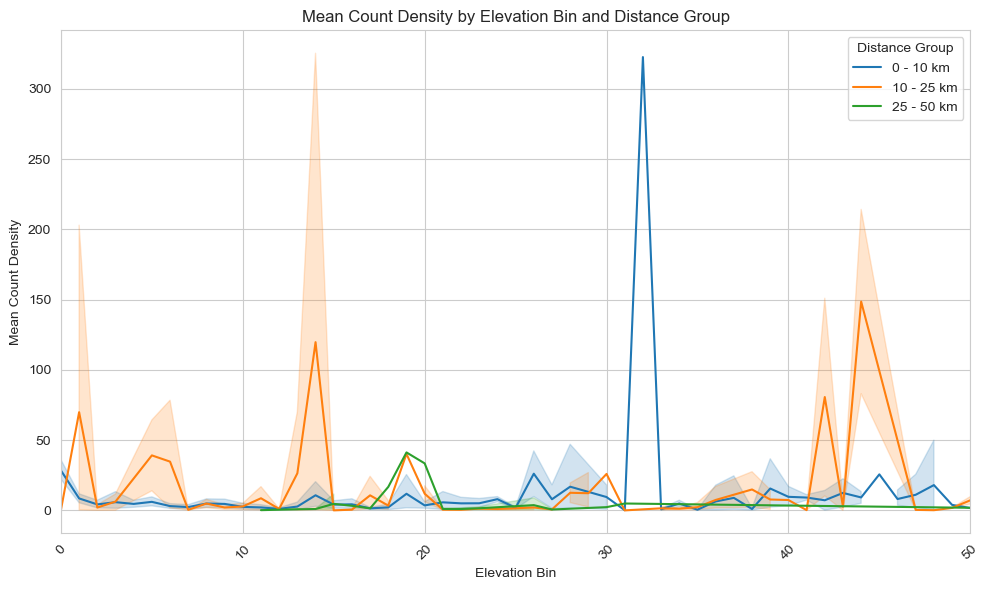

In [155]:
# Set the style
sns.set_style("whitegrid")

# Plot the line plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=polygon_count, x='elev_bin', y='count_density', hue='d_group')

# Add title and labels
plt.title('Mean Count Density by Elevation Bin and Distance Group')
plt.xlabel('Elevation Bin')
plt.ylabel('Mean Count Density')
plt.xticks(rotation=45)
plt.xlim(0,50)

# Show the plot
plt.legend(title='Distance Group')
plt.tight_layout()
plt.show()